In [ ]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL
from replay_trajectory_classification import (
    SortedSpikesClassifier,
    Environment,
    RandomWalk,
    Uniform,
    Identity,
    DiagonalDiscrete,
    make_track_graph,
)

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import cmap

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()

data_dir = RAW_DIR / "dual"
mouse_id = "103c"

STATE_NAMES = ["continuous", "fragmented", "stationary"]
BIN_SIZE_S = 0.001

sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
hd_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
head_direction = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

state_probs = [0.90, 0.95, 0.98, 0.99, 0.995, 0.9975, 0.999]
movement_vars = [0.5, 1.0, 2.0, 4.0, 8.0]

In [144]:
def get_environment(num_nodes: int = 360, place_bin_size: float = 1.0):
    radius = 180 / np.pi
    angle = np.linspace(2 * np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    n_nodes = len(track_graph.nodes)
    edge_order = np.stack(
        (np.roll(np.arange(n_nodes - 1, -1, -1), 1),
         np.arange(n_nodes - 1, -1, -1)),
        axis=1,
    )

    return Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=0,
    )

def fit_classifier(head_direction, train_spikes, movement_var=2.0, state_prob=0.99):
    environment = get_environment()
    continuous_transition_types = [
        [RandomWalk(movement_var=movement_var), Uniform(), Identity()],
        [Uniform(),                    Uniform(), Uniform()],
        [RandomWalk(movement_var=movement_var), Uniform(), Identity()],
    ]
    classifier = SortedSpikesClassifier(
        environments=environment,
        continuous_transition_types = continuous_transition_types,
        discrete_transition_type=DiagonalDiscrete(state_prob),
        )
    classifier.fit(head_direction, train_spikes)
    return classifier

In [ ]:
train_ep = head_direction.time_support
dt = 1/head_direction.rate
train_ep = nap.IntervalSet(train_ep.start - dt / 2, train_ep.end + dt / 2)
hd_units.count(bin_size=BIN_SIZE_S, ep=train_ep, time_units="s").astype(np.bool_)
train_data = hd_units.count(bin_size=BIN_SIZE_S, ep=train_ep, time_units="s").astype(np.bool_)

for state_prob in state_probs:
    # Training
    classifier = fit_classifier(head_direction.values, train_data.values, state_prob=state_prob)
    
    # Inference
    nrem_ep = sleep[sleep['state'] == 'nrem'][120]
    spikes = hd_units.count(bin_size=BIN_SIZE_S, ep=nrem_ep, time_units="s").astype(np.bool_)
    result = classifier.predict(spikes=spikes, time=spikes.times(), state_names=STATE_NAMES)

    states = nap.TsdFrame(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='position').to_numpy(), columns=result['state'])
    position = nap.Tsd(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='state').argmax(dim='position').to_numpy(),)
    
    states.save(INTERIM_DIR / "state_probs" / f"{mouse_id}_{state_prob}.npz")
    position.save(INTERIM_DIR / "state_probs" / f"{mouse_id}_{state_prob}_position.npz")

  0%|          | 0/64 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_analysis\.venv\Lib\site-packages\replay_trajectory_classification\core.py:210: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  discrete_state_transition[state_k, state_k_1]


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

In [254]:
result['acausal_posterior'].sum(dim='state').idxmax('position').to_numpy()

array([198.49748057, 198.49748057, 198.49748057, ...,  36.49953673,
        36.49953673,  36.49953673], shape=(128000,))

In [145]:
train_ep = head_direction.time_support
dt = 1/head_direction.rate
train_ep = nap.IntervalSet(train_ep.start - dt / 2, train_ep.end + dt / 2)
hd_units.count(bin_size=BIN_SIZE_S, ep=train_ep, time_units="s").astype(np.bool_)
train_data = hd_units.count(bin_size=BIN_SIZE_S, ep=train_ep, time_units="s").astype(np.bool_)

for movement_var in movement_vars:
    # Training
    classifier = fit_classifier(head_direction.values, train_data.values, movement_var=movement_var)
    
    # Inference
    nrem_ep = sleep[sleep['state'] == 'nrem'][120]
    spikes = hd_units.count(bin_size=BIN_SIZE_S, ep=nrem_ep, time_units="s").astype(np.bool_)
    result = classifier.predict(spikes=spikes, time=spikes.times(), state_names=STATE_NAMES)

    states = nap.TsdFrame(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='position').to_numpy(), columns=result['state'])
    position = nap.Tsd(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='state').argmax(dim='position').to_numpy(),)
    
    states.save(INTERIM_DIR / "movement_vars" / f"{mouse_id}_{movement_var}.npz")
    position.save(INTERIM_DIR / "movement_vars" / f"{mouse_id}_{movement_var}_position.npz")

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

In [147]:
tcs = classifier.place_fields_[('', 0)] * 1000
pref_angle = tcs.argmax(dim='position')
hd_spikes = hd_units.restrict(ep=nrem_ep)

In [225]:
window_size = 5000
start = 0
end = start + window_size

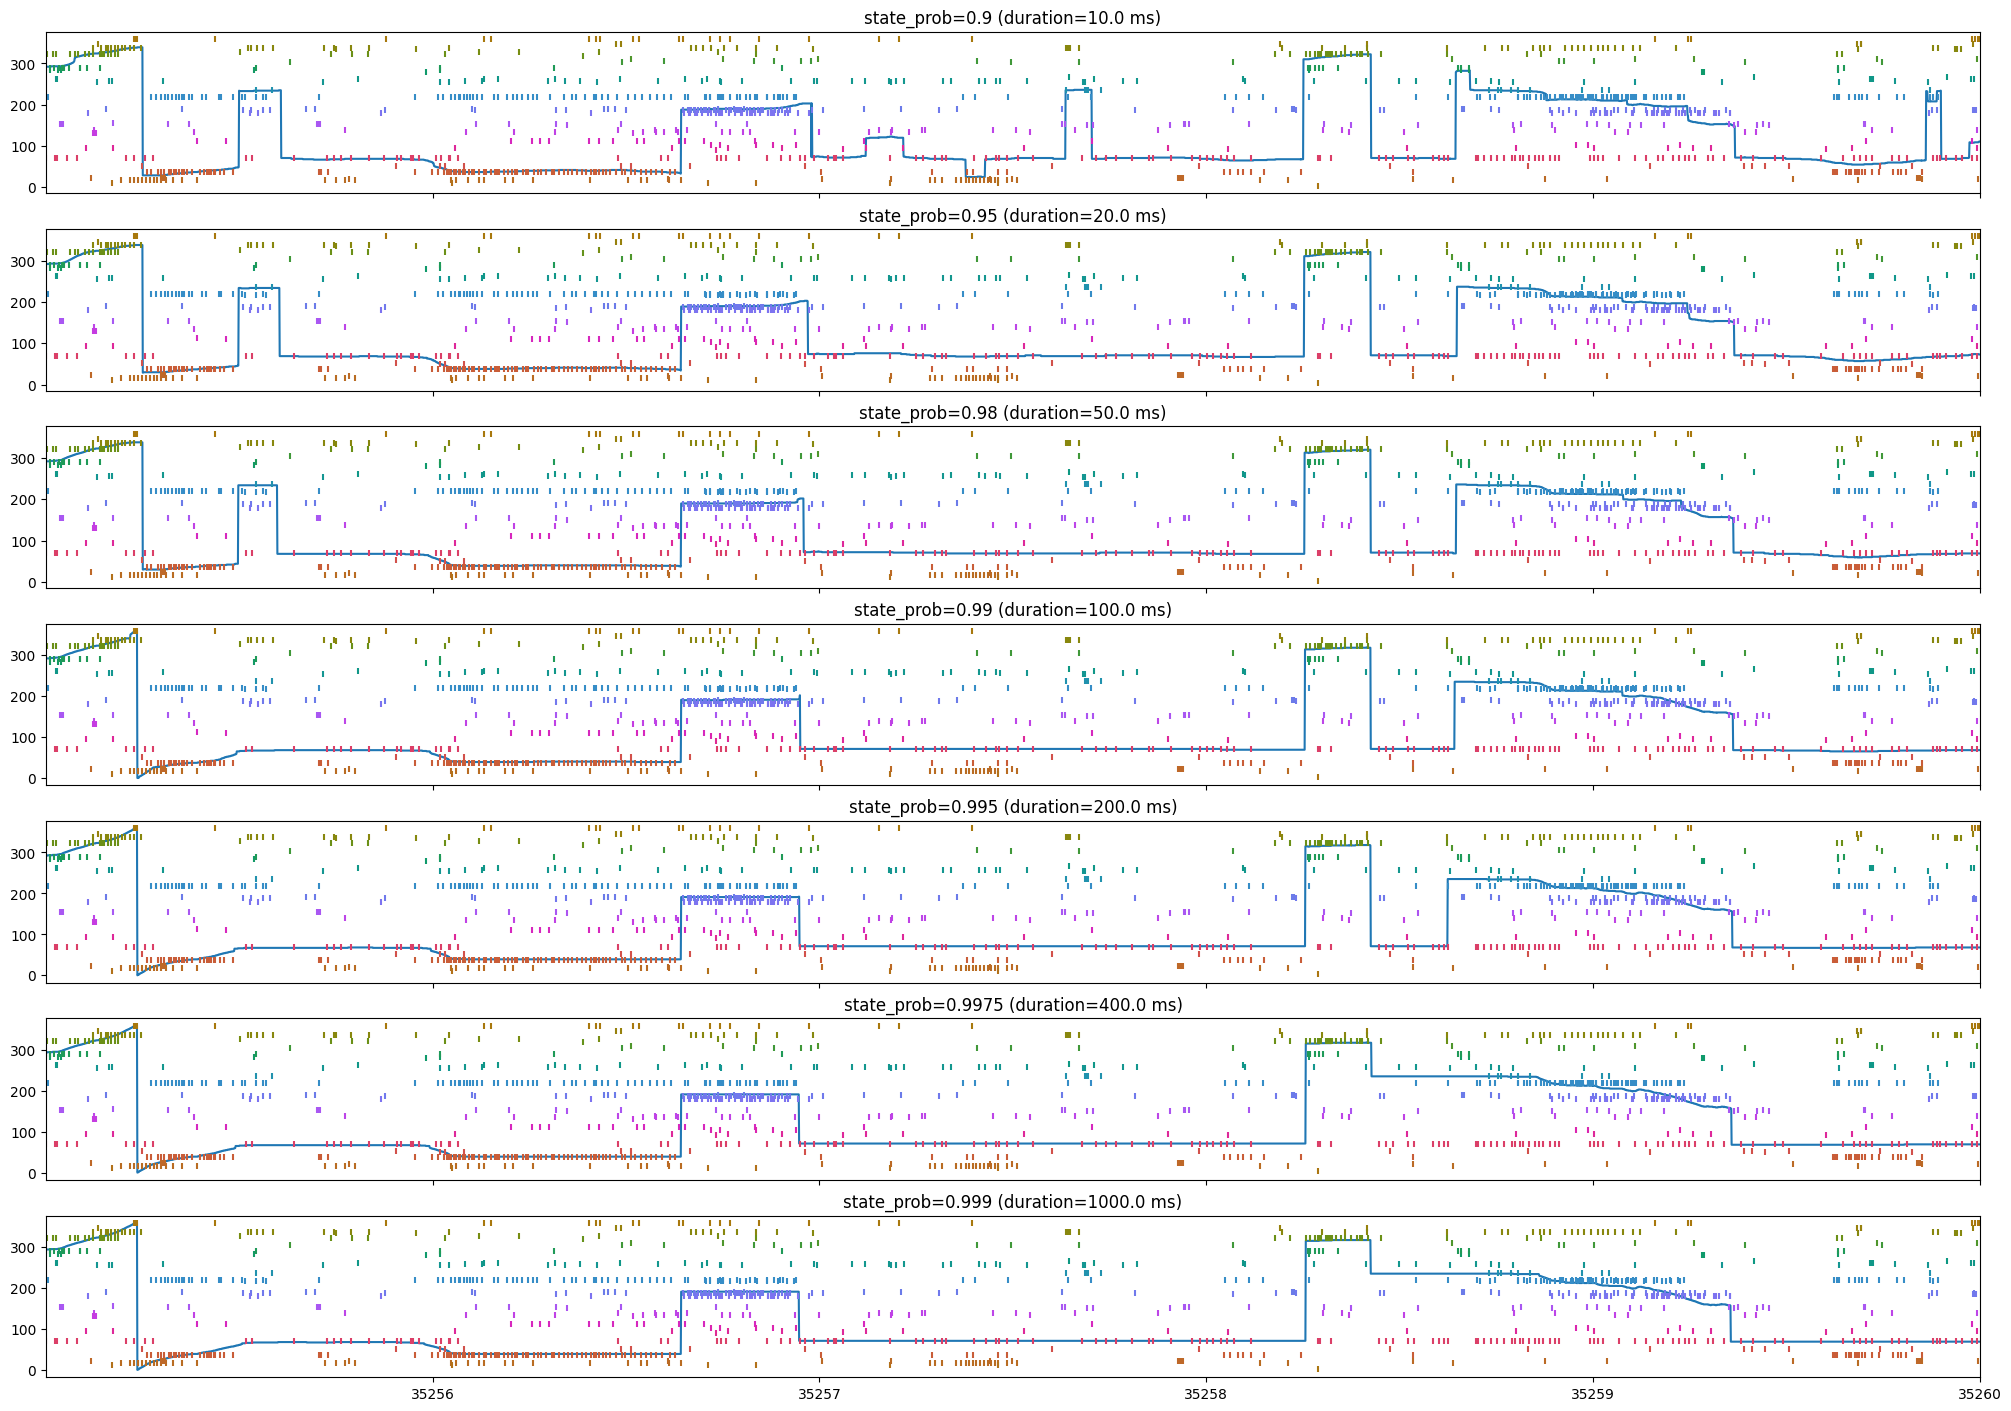

In [142]:
fig, axes = plt.subplots(nrows=len(state_probs), ncols=1, figsize=(20, 2 * len(state_probs)), sharex=True, constrained_layout=True)

start, end = end, end + window_size
for i, state_prob in enumerate(state_probs):
    # states = nap.load_file(INTERIM_DIR / f"{mouse_id}_{state_prob}.npz")
    position = nap.load_file(INTERIM_DIR / f"{mouse_id}_{state_prob}_position.npz")
    duration_ms = 1/(1-state_prob)
    
    axes[i].set_title(f"state_prob={state_prob} (duration={duration_ms:.1f} ms)")
    # axes[i].plot(states[start:end], label=states.columns.values)
    axes[i].plot(position[start:end])
    
    for j, n in enumerate(hd_spikes.keys()):
        pa = pref_angle[n].item()
        axes[i].plot(hd_spikes[n].fillna(pa), '|', color=cyclic_cmap(pa/360), markersize=5, markeredgewidth=1.5)
    axes[i].set_xlim(position.index[start], position.index[end])

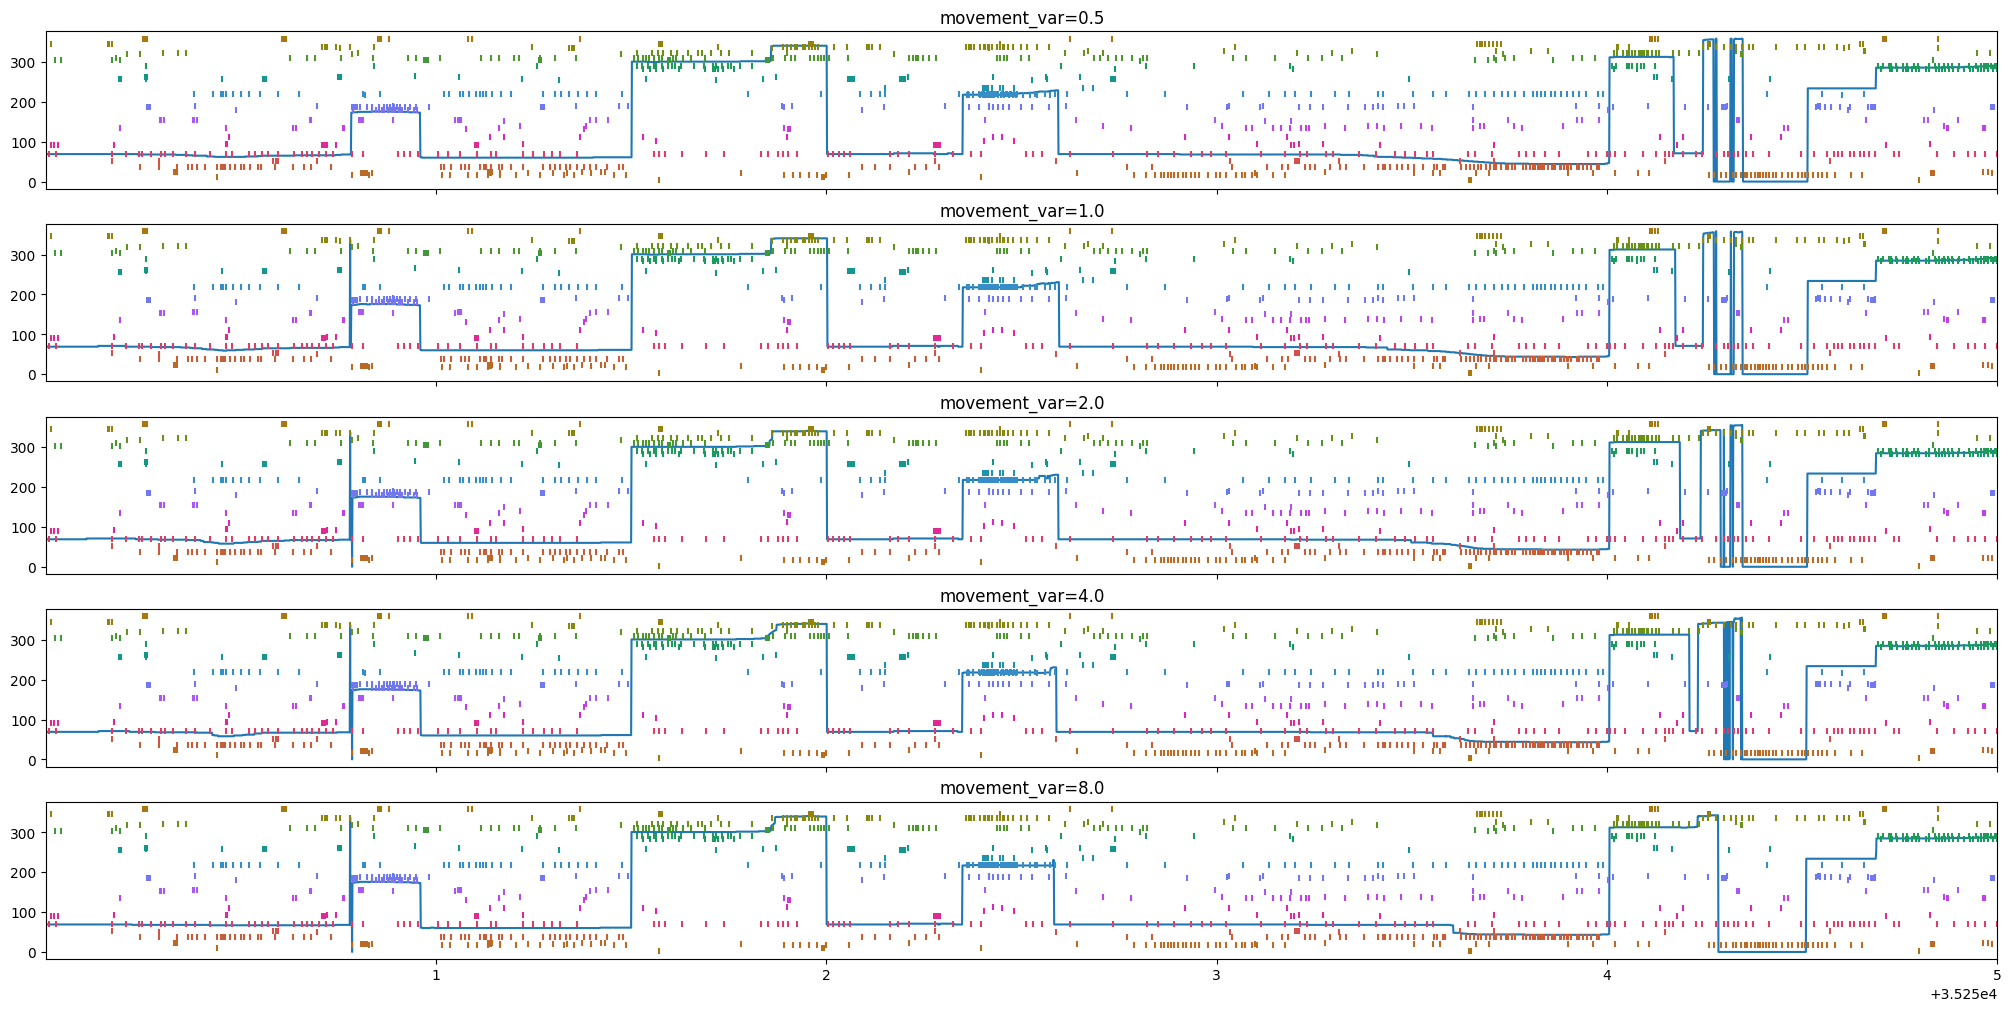

In [242]:
fig, axes = plt.subplots(nrows=len(movement_vars), ncols=1, figsize=(20, 2 * len(movement_vars)), sharex=True, constrained_layout=True)

start, end = end, end + window_size
for i, movement_var in enumerate(movement_vars):
    position = nap.load_file(INTERIM_DIR / "movement_vars" / f"{mouse_id}_{movement_var}_position.npz")
    axes[i].set_title(f"movement_var={movement_var}")
    axes[i].plot(position[start:end])
    
    for j, n in enumerate(hd_spikes.keys()):
        pa = pref_angle[n].item()
        axes[i].plot(hd_spikes[n].fillna(pa), '|', color=cyclic_cmap(pa/360), markersize=5, markeredgewidth=1.5)
    axes[i].set_xlim(position.index[start], position.index[end])